<a href="https://colab.research.google.com/github/Ruchirr999/csot-ml-astronomy/blob/main/submissions/Ruchirr999/week3/week3_cnn_starter_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 - ML in Astronomy - Week 3 . Part 1: A CNN and the Training Loop (Starter)

**Goal:** Replace the Week-2 MLP with a **Convolutional Neural Network**, then write the **training loop** that teaches it. By the end you'll watch the training loss fall over several epochs.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). This week it actually matters for speed.
2. Read [`01-convolutions-and-pooling.md`](../01-convolutions-and-pooling.md), [`02-building-a-cnn.md`](../02-building-a-cnn.md), and [`03-the-training-loop.md`](../03-the-training-loop.md).

Replace each `TODO` with working code. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Re-create the Week 1 data pipeline

Week 3 builds directly on the `DataLoader`s from Week 1. Paste that pipeline below (download is commented out in the Week-1 solution - uncomment it the first time). If you saved `galaxy_data/` to Google Drive in Week 1, re-mount Drive and point `ImageFolder` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [ ]:
import math
import os
import random
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [ ]:
# TODO: paste your Week 1 data pipeline here so that the following names are defined:
#   train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, num_classes
#
# The quickest path is to copy the data-prep cells from
# ../../Week-1/notebooks/week1_data_solution.ipynb (Steps 1-8), then add:
#   num_classes = len(train_ds.classes)
#   print("classes:", train_ds.classes, "num_classes:", num_classes)
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2/images"   # adjust if your JPGs landed one folder deeper
DATA_ROOT = Path("galaxy_data")        # we create train/val/test subfolders here
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"


# # Download Galaxy Zoo 2 images dataset
# !kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
# # Create raw data folder
# !mkdir -p galaxy_raw
# # Unzip dataset
# !unzip -q galaxy-zoo-2-images.zip -d galaxy_raw
# # Download Hart et al. labels
# !wget -q -O galaxy_raw/gz2_hart16.csv.gz \
# https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
# # Unzip labels csv
# !gunzip -f galaxy_raw/gz2_hart16.csv.gz

print("RAW_ROOT   =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT  =", DATA_ROOT)

print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

print("\nMapping CSV preview:")
print(pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3))

print("\nLabels CSV preview (note dr7objid — we rename to objid before merging):")
print(pd.read_csv(RAW_ROOT / "gz2_hart16.csv", nrows=3)[["dr7objid", "gz2_class"]])

def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, …) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None  # artifact / ambiguous
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None
def load_labeled_table(mapping_csv, labels_csv):
    """Join Kaggle mapping (objid ↔ asset_id) with Hart et al. morphology labels."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    return df


def _link_image(src: Path, dst: Path) -> bool:
    """Symlink if possible; otherwise copy (some Drive setups block symlinks)."""
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True

def build_split_imagefolder_layout(
    images_dir,
    df,
    out_root,
    per_class=200,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
):
    """Create out_root/{train,val,test}//*.jpg for ImageFolder."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    images_dir = Path(images_dir)
    out_root = Path(out_root)
    summary = {}

    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)

        n = len(rows)
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)
        n_test = n - n_train - n_val
        splits = {
            "train": rows.iloc[:n_train],
            "val": rows.iloc[n_train : n_train + n_val],
            "test": rows.iloc[n_train + n_val :],
        }

        summary[label] = {}
        for split_name, split_rows in splits.items():
            linked = 0
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists() and _link_image(src, dst):
                    linked += 1
            summary[label][split_name] = linked
    return summary

df = load_labeled_table(
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
)
print("Joined rows:", len(df))
print("\nLabel counts:")
print(df["label"].value_counts())
print("\nExample rows:")
print(df[["asset_id", "objid", "gz2_class", "label"]].head())
PER_CLASS = 200  # increase once the pipeline works (e.g. 2000)

summary = build_split_imagefolder_layout(
    IMAGES_DIR,
    df,
    DATA_ROOT,
    per_class=PER_CLASS,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
)
print("Linked images per class and split:")
print(pd.DataFrame(summary).fillna(0).astype(int))

for split in ("train", "val", "test"):
    split_dir = DATA_ROOT / split
    classes = sorted(p.name for p in split_dir.iterdir() if p.is_dir()) if split_dir.exists() else []
    n_imgs = sum(1 for _ in split_dir.rglob("*.jpg")) if split_dir.exists() else 0
    print(f"{split:5s}: {n_imgs:4d} images  classes={classes}")
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    print(f"{name:5s}  n={len(ds):4d}  classes={ds.classes}")

print("class_to_idx:", train_ds.class_to_idx)
image, label = train_ds[0]
print("shape :", image.shape)
print("dtype :", image.dtype)
print("label :", label, "->", train_ds.classes[label])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print("train batch images:", images.shape)   # (32, 3, 64, 64)
print("train batch labels:", labels.shape)     # (32,)

num_classes = len(train_ds.classes)
print("classes:", train_ds.classes, "num_classes:", num_classes)

RAW_ROOT   = galaxy_raw
IMAGES_DIR = galaxy_raw/images_gz2/images
DATA_ROOT  = galaxy_data
RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434

Mapping CSV preview:
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3

Labels CSV preview (note dr7objid — we rename to objid before merging):
             dr7objid gz2_class
0  587732591714893851      Sc+t
1  588009368545984617      Sb+t
2  587732484359913515        Ei
Joined rows: 239100

Label counts:
label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64

Example rows:
   asset_id               objid gz2_class       label
0         3  587722981741363294        Sb      spiral
1         4  587722981741363323      Sc?l      spiral
2         5  587722981741559888        Er  elliptical
3         6  58

## Step 1 - Define the CNN

Two `Conv -> ReLU -> Pool` blocks (channels `3 -> 16 -> 32`, each conv `kernel_size=3, padding=1`), then a `Flatten -> Linear -> ReLU -> Linear` head. With a 64x64 input and two 2x2 pools, the feature maps are `(B, 32, 16, 16)`, so the flattened size is `32*16*16 = 8192`. The final layer returns **raw logits** (no softmax). Don't forget `super().__init__()`.

In [ ]:
# TODO: define GalaxyCNN(nn.Module).
#   features = nn.Sequential(
#       nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
#       nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
#   classifier = nn.Sequential(
#       nn.Flatten(), nn.Linear(32*16*16, 128), nn.ReLU(), nn.Linear(128, num_classes))
#   forward(x): x = features(x); x = classifier(x); return x
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Define the feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Define the classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Step 2 - Instantiate and move to the device

Use the real `num_classes` from your data, and `.to(device)` so the model lives where the batches will.

In [ ]:
# TODO: model = GalaxyCNN(num_classes=num_classes).to(device)
#       print(model)
model = GalaxyCNN(num_classes=num_classes).to(device)
print(model)


GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Step 3 - Forward-pass one real batch and count parameters

Pull a batch from `train_loader`, move it to the device, and confirm the output is `(batch_size, num_classes)`. Then print the parameter count - notice the convolutions are tiny and the first `Linear` dominates (compare with the Week-2 MLP's ~1.57M first layer).

In [ ]:
# TODO: images, labels = next(iter(train_loader)); move both to device.
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

#       logits = model(images); print(logits.shape)  # expect (B, num_classes)
logits = model(images)
print(logits.shape)

#       total = sum(p.numel() for p in model.parameters()); print(f"params: {total:,}")
total = sum(p.numel() for p in model.parameters())
print(f"params: {total:,}")

torch.Size([32, 3])
params: 1,054,179


## Step 4 - Loss, optimiser, and a starting-loss sanity check

`CrossEntropyLoss` consumes raw logits + integer labels. `Adam` with `lr=1e-3` is the sensible default. An untrained model on `C` balanced classes should give a loss near `ln(C)`.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
#       loss = criterion(logits, labels); print(loss.item(), "vs ln(C) =", math.log(num_classes))
loss = criterion(logits, labels)
print(loss.item(), "vs ln(C) =", math.log(num_classes))

1.103166103363037 vs ln(C) = 1.0986122886681098


## Step 5 - The training loop

For each epoch, loop over `train_loader` and run the **five steps** every batch: `zero_grad -> forward -> loss -> backward -> step`. Accumulate a running loss and store the epoch average in `train_losses`. Call `model.train()` at the start of each epoch and `.to(device)` every batch.

In [ ]:
# TODO: write the training loop.

num_epochs = 38
train_losses = []
for epoch in range(num_epochs):
    model.train(); running = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running += loss.item() * inputs.size(0)
    epoch_loss = running / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{num_epochs}  train loss: {epoch_loss:.4f}")

Epoch  1/30  train loss: 0.9657
Epoch  2/30  train loss: 0.9534
Epoch  3/30  train loss: 0.9129
Epoch  4/30  train loss: 0.9642
Epoch  5/30  train loss: 0.8830
Epoch  6/30  train loss: 0.8494
Epoch  7/30  train loss: 0.8369
Epoch  8/30  train loss: 0.8030
Epoch  9/30  train loss: 0.7594
Epoch 10/30  train loss: 0.7354
Epoch 11/30  train loss: 0.7211
Epoch 12/30  train loss: 0.6859
Epoch 13/30  train loss: 0.6649
Epoch 14/30  train loss: 0.6376
Epoch 15/30  train loss: 0.6479
Epoch 16/30  train loss: 0.6597
Epoch 17/30  train loss: 0.5602
Epoch 18/30  train loss: 0.5356
Epoch 19/30  train loss: 0.5385
Epoch 20/30  train loss: 0.5020
Epoch 21/30  train loss: 0.5119
Epoch 22/30  train loss: 0.4806
Epoch 23/30  train loss: 0.4746
Epoch 24/30  train loss: 0.4507
Epoch 25/30  train loss: 0.4337
Epoch 26/30  train loss: 0.4073
Epoch 27/30  train loss: 0.3838
Epoch 28/30  train loss: 0.3972
Epoch 29/30  train loss: 0.3687
Epoch 30/30  train loss: 0.3186


## Step 6 - Plot the loss curve

A healthy run shows `train_losses` trending **down**. Small wiggles are fine; the trend is what matters.

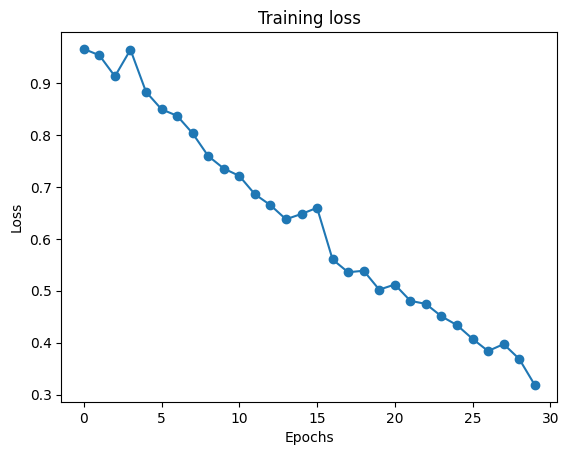

In [ ]:
plt.plot(train_losses, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss')
plt.show()
#played a bit with the number of epochs that is why the number of epochs in shown graph are more

## Step 7 (stretch) - Save Part 1's weights for Part 2

Optional but handy: save the trained weights so the Part-2 notebook can load them instead of re-training. Save to Drive so they survive a runtime recycle. (Saving/loading is covered fully in [`07-saving-and-loading-models.md`](../07-saving-and-loading-models.md).)

In [ ]:
# TODO (optional): torch.save(model.state_dict(), 'galaxy_model.pth'); print('saved')
torch.save(model.state_dict(), 'galaxy_model.pth')
print('saved')

saved


### Reflection

1. **Parameter Distribution:** Most of the weights live in the **first fully connected (linear) layer** right after flattening the feature maps ($32 \times 16 \times 16 = 8,192$ inputs connecting to $128$ outputs). This is vastly different from the Week-2 MLP because convolutional layers use small, shared kernels to scan the image, keeping the parameter count incredibly low. The MLP, by contrast, connects every single input pixel to every hidden neuron, resulting in a massive, inefficient weight matrix right from the start.

2. **Loss Curve Analysis:** The training-loss curve shows a healthy, **steadily downward trend** over the 30 epochs, decreasing from roughly 0.40 to 0.31 with minor wiggles. If the loss never fell, it would indicate **underfitting**, meaning the model failed to learn anything due to a bad learning rate or a lack of capacity. If the loss went to `nan`, it would signal **numerical instability** (like exploding gradients or division by zero), meaning the network's weights became too large to compute.

3. **Beyond Training Loss:** Part 2 adds a **validation dataset evaluation loop** to monitor model accuracy on unseen data. This is crucial because a low training loss only proves the model has memorized the training images. Evaluating it on a separate validation set ensures the model has actually learned to generalize features for real astronomical classification rather than just overfitting.